# Task 1: Gradient Descent

---



## Objective
In this lab, you will implement missing parts of a **gradient descent** workflow for **unconstrained optimization**.

You will work with **two different 1D objective functions** (called `f1` and `f2`) and study how gradient descent behaves under **different learning rates**.


Your task is to implement the missing parts (marked as **TODO**) in the code:
- the **objective functions**,
- their **gradients**,
- and a **gradient descent** routine with stopping criteria and divergence checks.


## Overview
Gradient descent updates a parameter $x$ by moving in the negative gradient direction:

$x_{t+1} = x_t - \eta \, \nabla f(x_t)$

where:
- $f(x)$ is the objective function,
- $\nabla f(x)$ is its gradient (derivative in 1D),
- $\eta > 0$ is the learning rate.

### Learning rate intuition
The learning rate $\eta$ controls the **step size**:
- If $\eta$ is **too small**, steps are tiny and convergence can be **very slow**.
- If $\eta$ is **too large**, steps can **overshoot** and the iterates may **oscillate** or **diverge**.
- Often there is an **intermediate range** where the method is both **stable** and **fast**.

In this lab, you will visualize trajectories to build intuition for these regimes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## SubTask 0: Implement the Objectives

Complete the functions `f1(x)` and `f2(x)` defined as:
$$
f_1(x) = (x^2 - 1)^2 + x
$$
and
$$
f_2(x) = 10 (x - 2)^2
$$

- Each function takes a single float `x` and returns a float.
- Implement them using basic Python/NumPy operations.


In [ ]:

def f1(x: float) -> float:
    """
    Implement objective f1.

    """
    return (x**2 - 1)**2 + x


def f2(x: float) -> float:
    """
    Implement objective f2.

    """
    return 10 * (x - 2)**2


640


## SubTask 1: Visualize Both Objectives

Run the plotting code after you complete **SubTask 0**.  

As you inspect the plots, consider:
- How many “valleys” (minima) do you see?
- Do you suspect the optimization landscape might trap gradient descent depending on initialization and step size?


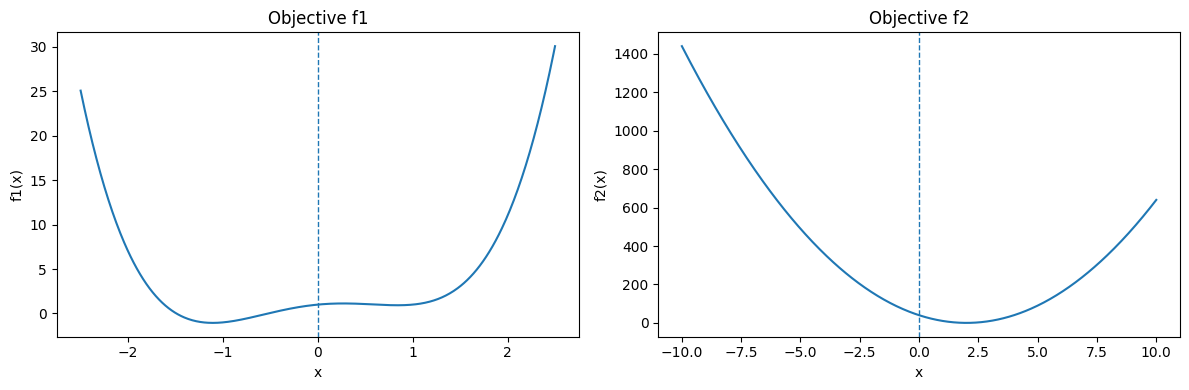

In [4]:

def plot_objectives() -> None:
    """Run this after you implement f1 and f2 (Task 0)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot for f1
    xs1 = np.linspace(-2.5, 2.5, 600)
    ys1 = [f1(x) for x in xs1]
    axes[0].plot(xs1, ys1)
    axes[0].set_title("Objective f1")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("f1(x)")
    axes[0].axvline(0.0, linestyle="--", linewidth=1)

    # Plot for f2
    xs2 = np.linspace(-10, 10, 600)
    ys2 = [f2(x) for x in xs2]
    axes[1].plot(xs2, ys2)
    axes[1].set_title("Objective f2")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("f2(x)")
    axes[1].axvline(0.0, linestyle="--", linewidth=1)

    plt.tight_layout()
    plt.show()
plot_objectives()

## SubTask 2: Compute and Implement the Gradients

Compute the derivatives by hand and implement them.

- `grad_f1(x)` should return $ \frac{d}{dx} f_1(x) $
- `grad_f2(x)` should return $ \frac{d}{dx} f_2(x) $

Hints:
- Use the **chain rule** where needed.
- In 1D, “gradient” means “derivative”.


In [1]:

def grad_f1(x: float) -> float:
    """
    Derivative of:
        f1(x) = (x^2 - 1)^2 + x
    """
    return 4*x**3 - 4*x + 1


def grad_f2(x: float) -> float:
    """
    Derivative of:
        f2(x) = 10 (x - 2)^2
    """
    return 20 * (x - 2)



## SubTask 3: Implement Gradient Descent

Complete `gradient_descent(...)`.

Your implementation must:
1. Update the iterates according to the gradient descent update rule
2. Store all iterates in `history`
3. Stop early if a convergence criterion is met
4. Detect divergence (non-finite values, or very large |x|)

Return:
- `x_final` (float)
- `history` (np.ndarray)
- `status` in `{ "converged", "max_steps", "diverged" }`


In [ ]:

def gradient_descent(
    grad_fn,
    f_fn,
    x0: float,
    lr: float,
    n_steps: int = 200,
    tol: float = 1e-6,
    divergence_bound: float = 1e6,
):
    """
    Runs gradient descent on a 1D objective.

    Returns
    -------
    x_final : float
        Final iterate
    history : np.ndarray
        All iterates x_0, x_1, ..., x_T
    status : str
        One of: "converged", "max_steps", "diverged"
    """
    x = float(x0)
    history = [x]

    for t in range(n_steps):
        g = grad_fn(x)

        # (3a) Gradient descent update
        x = x - lr * g

        # (3b) Track history
        #TODO: Uncomment
        history.append(x)

        # (3c) Convergence check
        if abs(grad_fn(x)) < tol:
            return x, np.array(history), "converged"

        # (3d) Divergence detection
        if (not np.isfinite(x)) or (abs(x) > divergence_bound) or (not np.isfinite(f_fn(x))):
            return x, np.array(history), "diverged"

    return x, np.array(history), "max_steps"


## SubTask 4: Compare Learning Rates by Plotting Trajectories

### What you should learn from these plots
When you compare different learning rates $\eta$, look for:
- **Speed:** how quickly $x_t$ approaches a stable value (if it does).
- **Stability:** whether the iterates settle down vs. oscillate or blow up.
- **Sensitivity:** whether changing $\eta$ changes the region of the landscape explored (especially on objectives with multiple “valleys”).

You are given a few learning rates to try, but you are encouraged to experiment with your own as well.

**Instructions:** Run the cell below after completing the TODOs. It will:
1. run gradient descent for each learning rate,
2. print the final outcome (`status`, final `x`, and final objective value),
3. plot trajectories $x_t$ vs iteration,
4. plot the iterates on top of each objective curve.



=== Runs for f1 ===
lr=0.03    status=converged  x_final= 0.837566  f1(x_final)= 0.926658
lr=0.08    status=converged  x_final=-1.107160  f1(x_final)=-1.056173
lr=0.1     status=converged  x_final=-1.107160  f1(x_final)=-1.056173
lr=0.18    status=diverged   x_final= 6854402.745492  f1(x_final)= 2207386972325195578114834432.000000

=== Runs for f2 ===
lr=0.001   status=max_steps  x_final= 1.824121  f2(x_final)= 0.309336
lr=0.04    status=converged  x_final= 2.000000  f2(x_final)= 0.000000
lr=0.8     status=diverged   x_final= 7593752.000000  f2(x_final)= 576650390625000.000000
lr=0.12    status=diverged   x_final= 1301613.115516  f2(x_final)= 16941914960337.953125


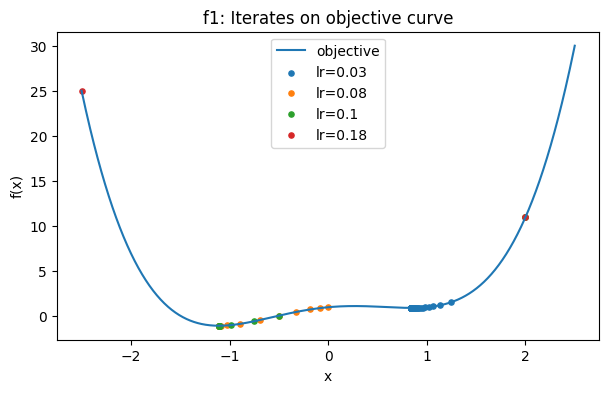

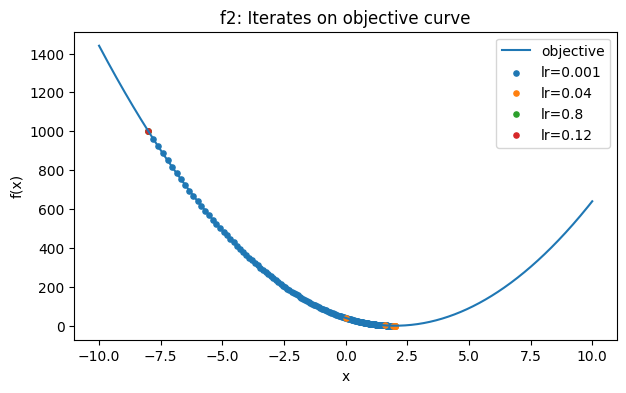

In [ ]:

def plot_trajectories_for_objective(f_fn, histories, lrs, x_min, x_max, title_prefix=""):
    """
    Plot ONLY: iterates overlaid on the objective curve.

    - The objective curve is plotted on the fixed interval [x_min, x_max]
      (this is the "original x-axis", independent of the iterates).
    - Any iterate that leaves [x_min, x_max] (or becomes non-finite) is NOT plotted.
    """

    # Objective curve on the ORIGINAL x-axis range
    xs = np.linspace(x_min, x_max, 800)
    ys = [f_fn(x) for x in xs]

    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys, label="objective")

    for hist, lr in zip(histories, lrs):
        hist = np.asarray(hist)

        # Keep only iterates that stay within the original axis range and are finite
        in_range = (hist >= x_min) & (hist <= x_max) & np.isfinite(hist)
        hist_in = hist[in_range]

        # If everything moved out of range, skip plotting this trajectory
        if hist_in.size == 0:
            continue

        # Also guard against non-finite objective values
        vals = np.array([f_fn(x) for x in hist_in])
        ok = np.isfinite(vals)

        if np.any(ok):
            plt.scatter(hist_in[ok], vals[ok], s=14, label=f"lr={lr}")

    plt.title(f"{title_prefix}Iterates on objective curve")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.show()


def run_and_plot() -> None:
    # Choose learning rates to test
    x0_f1 = 2.0
    lrs_f1 = [0.03, 0.08, 0.1, 0.18]

    x0_f2 = -8.0
    lrs_f2 = [0.001, 0.04, 0.8, 0.12]

    print("\n=== Runs for f1 ===")
    histories_f1 = []
    for lr in lrs_f1:
        x_fin, hist, status = gradient_descent(
            grad_fn=grad_f1,
            f_fn=f1,
            x0=x0_f1,
            lr=lr,
            n_steps=200,
        )
        histories_f1.append(hist)
        print(f"lr={lr:<7} status={status:<10} x_final={x_fin: .6f}  f1(x_final)={f1(x_fin): .6f}")

    print("\n=== Runs for f2 ===")
    histories_f2 = []
    for lr in lrs_f2:
        x_fin, hist, status = gradient_descent(
            grad_fn=grad_f2,
            f_fn=f2,
            x0=x0_f2,
            lr=lr,
            n_steps=200,
        )
        histories_f2.append(hist)
        print(f"lr={lr:<7} status={status:<10} x_final={x_fin: .6f}  f2(x_final)={f2(x_fin): .6f}")

    # Plot iterates only (within the original x-axis ranges)
    plot_trajectories_for_objective(
        f_fn=f1,
        histories=histories_f1,
        lrs=lrs_f1,
        x_min=-2.5,
        x_max=2.5,
        title_prefix="f1: ",
    )

    plot_trajectories_for_objective(
        f_fn=f2,
        histories=histories_f2,
        lrs=lrs_f2,
        x_min=-10,
        x_max=10,
        title_prefix="f2: ",
    )
run_and_plot()

## (Optional) Gradient Sanity Check (Finite Differences)

This is optional. It can help you debug sign errors or missing factors in your gradient.

It compares your analytical gradient to a finite-difference approximation at a few points.


In [12]:
def finite_diff_grad(f, x, eps=1e-6):
    return (f(x + eps) - f(x - eps)) / (2 * eps)

# Uncomment after implementing f1/f2 and grad_f1/grad_f2
test_points = [-2.0, -0.5, 0.0, 0.8, 2.0]
for x in test_points:
    print("x =", x)
    print("  grad_f1(x) =", grad_f1(x), "  fd =", finite_diff_grad(f1, x))
    print("  grad_f2(x) =", grad_f2(x), "  fd =", finite_diff_grad(f2, x))


x = -2.0
  grad_f1(x) = -23.0   fd = -23.000000000550358
  grad_f2(x) = -80.0   fd = -80.00000001118224
x = -0.5
  grad_f1(x) = 2.5   fd = 2.4999999999886224
  grad_f2(x) = -50.0   fd = -50.00000000521254
x = 0.0
  grad_f1(x) = 1.0   fd = 0.9999999999732445
  grad_f2(x) = -40.0   fd = -39.99999999848569
x = 0.8
  grad_f1(x) = -0.1519999999999997   fd = -0.1520000000310162
  grad_f2(x) = -24.0   fd = -23.999999997137422
x = 2.0
  grad_f1(x) = 25.0   fd = 24.999999999941735
  grad_f2(x) = 0.0   fd = 2.2204459931571278e-15
